## <font color = EF6905> step 1 : Business Understanding

* Model 1 — Flood Event Prediction

ทำนายว่า:


```
flood_event_occurred
       ↓
       0 = No Flood
       1 = Flood
```

ex.
จาก Rainfall + River Level + Soil Moisture + Temperature + Historical Data → มีโอกาสเกิด Flood หรือไม่?

* Model 2 — Flood Severity Prediction

ทำนาย:


```
severity_level

Low
Moderate
High
Very High
Extreme
```
หรืออาจใช้ flood_risk_score เป็น Regression Target


```
Input
   ↓
ML Model
   ↓
Flood Risk Score
```
ซึ่งจะทำให้ Project มีทั้ง Classification + Regression ได้



* Dashboard Structure

ตัวอย่างหน้าแรก:

```
┌──────────────────────────────────────────────────────────┐
│              ASIA FLOOD RISK ATLAS                       │
│                  2000 – 2024                             │
├────────────┬────────────┬────────────┬──────────────────┤
│ Stations   │ Countries  │ Flood      │ Avg Risk Score   │
│    XXX     │    XX      │ Events XXX │      X.XX        │
├────────────┴────────────┴────────────┴──────────────────┤
│                                                          │
│                 FLOOD RISK MAP                           │
│                                                          │
│       🟢 🟢 🟡 🟠 🔴                                    │
│                                                          │
├─────────────────────────┬────────────────────────────────┤
│ Flood Risk Trend        │ Flood Events by Country        │
│                         │                                │
│       📈                │ India      █████████           │
│                         │ Thailand   ███████             │
│                         │ Vietnam    █████               │
└─────────────────────────┴────────────────────────────────┘
```

แล้วสามารถทำหน้าแยกสำหรับ

Overview → Map → Country → Station → Trend → Risk Analysis → ML Prediction

## <font color = EF6905> step 2 :  Data Acquisition

In [ ]:
import os
import pandas as pd

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aliahmadmphil/asia-flood-25-year-flood-risk-atlas-2000-2024")

print("Path to dataset files:", path)

100%|██████████| 12.8M/12.8M [00:00<00:00, 46.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aliahmadmphil/asia-flood-25-year-flood-risk-atlas-2000-2024/versions/1


In [ ]:
# Construct the full path to the nested dataset directory
dataset_dir = os.path.join(path, 'ASIA_FLOOD_25YEAR_DATASET')

# List the contents of the nested dataset directory
print(f"Contents of the dataset directory '{dataset_dir}':")
for item in os.listdir(dataset_dir):
    print(f"- {item}")


Contents of the dataset directory '/root/.cache/kagglehub/datasets/aliahmadmphil/asia-flood-25-year-flood-risk-atlas-2000-2024/versions/1/ASIA_FLOOD_25YEAR_DATASET':
- README.md
- documentation
- data


In [ ]:
# Construct the full path to the 'data' subdirectory
data_dir = os.path.join(dataset_dir, 'data')

# List the contents of the 'data' directory
print(f"Contents of the 'data' directory '{data_dir}':")
for item in os.listdir(data_dir):
    print(f"- {item}")

Contents of the 'data' directory '/root/.cache/kagglehub/datasets/aliahmadmphil/asia-flood-25-year-flood-risk-atlas-2000-2024/versions/1/ASIA_FLOOD_25YEAR_DATASET/data':
- station_daily_data.csv
- vulnerability_data.csv
- station_daily_data_full.csv
- asia_flood_geospatial.geojson


In [ ]:
file_path = os.path.join(data_dir, "station_daily_data_full.csv")
df_load = pd.read_csv(file_path)

# Display the head of the dataframe to confirm it loaded correctly
display(df_load.head())

,station_id,station_name,basin,country,latitude,longitude,date,year,month,day,...,rainfall_mm,river_level_m,soil_moisture_percent,temperature_celsius,flood_risk_score,flood_event_occurred,severity_level,season,monsoon_season,data_quality_score
0,ASIA_0001,Varanasi,Ganges,India,25.4401,85.9955,2000-01-01,2000,1,1,...,4.55,1.35,15.66,21.30,1.89,0,Low,Winter,0,0.986
1,ASIA_0001,Varanasi,Ganges,India,25.4401,85.9955,2000-01-02,2000,1,2,...,5.58,3.70,27.19,18.48,1.89,0,Low,Winter,0,0.965
2,ASIA_0001,Varanasi,Ganges,India,25.4401,85.9955,2000-01-03,2000,1,3,...,9.93,3.51,18.11,20.93,2.53,0,Low,Winter,0,0.926
3,ASIA_0001,Varanasi,Ganges,India,25.4401,85.9955,2000-01-04,2000,1,4,...,5.72,2.91,19.20,19.86,2.28,0,Low,Winter,0,0.908
4,ASIA_0001,Varanasi,Ganges,India,25.4401,85.9955,2000-01-05,2000,1,5,...,9.45,4.53,26.70,17.37,2.55,0,Low,Winter,0,0.942


## <font color = EF6905> step 3 : Data Preparation & Cleaning

In [ ]:
df_clean = df_load.copy()

* Data Profilin

### 1) ข้อความตัวเอียง ตรวจ Missing Values and Dtype

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456600 entries, 0 to 456599
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   station_id             456600 non-null  object 
 1   station_name           456600 non-null  object 
 2   basin                  456600 non-null  object 
 3   country                456600 non-null  object 
 4   latitude               456600 non-null  float64
 5   longitude              456600 non-null  float64
 6   date                   456600 non-null  object 
 7   year                   456600 non-null  int64  
 8   month                  456600 non-null  int64  
 9   day                    456600 non-null  int64  
 10  day_of_year            456600 non-null  int64  
 11  rainfall_mm            456600 non-null  float64
 12  river_level_m          456600 non-null  float64
 13  soil_moisture_percent  456600 non-null  float64
 14  temperature_celsius    456600 non-nu

<font color = pink> This dataset has no missing values ​​in any of the columns.


### 2) ตรวจ Duplicate

In [ ]:
df_clean.duplicated().sum()

np.int64(0)

<font color = pink> This dataset contains no duplicate data.

### 3) ตรวจ Outlier

In [ ]:
df_clean.describe()

,latitude,longitude,year,month,day,day_of_year,rainfall_mm,river_level_m,soil_moisture_percent,temperature_celsius,flood_risk_score,flood_event_occurred,monsoon_season,data_quality_score
count,456600.000000,456600.000000,456600.000000,456600.000000,456600.000000,456600.000000,456600.000000,456600.000000,456600.000000,456600.000000,456600.000000,456600.000000,456600.000000,456600.000000
mean,23.041408,93.048206,2012.000000,6.522558,15.730727,183.140276,20.280950,5.570613,36.938060,24.493418,3.438981,0.021658,0.418857,0.934921
std,5.366186,15.931998,7.211748,3.448809,8.800562,105.447452,41.921252,5.652385,18.149693,10.485583,1.667038,0.145564,0.493372,0.031741
min,12.710400,60.547800,2000.000000,1.000000,1.000000,1.000000,2.020000,0.660000,0.390000,-2.310000,1.000000,0.000000,0.000000,0.880000
25%,18.649000,85.165400,2006.000000,4.000000,8.000000,92.000000,5.720000,3.160000,22.070000,15.250000,2.090000,0.000000,0.000000,0.907000
50%,23.969600,96.982550,2012.000000,7.000000,16.000000,183.000000,10.760000,4.420000,31.000000,24.490000,2.920000,0.000000,0.000000,0.935000
75%,27.098600,103.075600,2018.000000,10.000000,23.000000,274.000000,25.950000,6.790000,52.570000,33.770000,4.750000,0.000000,1.000000,0.962000
max,33.475200,115.837900,2024.000000,12.000000,31.000000,366.000000,1775.720000,204.670000,100.000000,45.000000,10.000000,1.000000,1.000000,0.990000


### 4) ตรวจช่วงปี/วันที่

In [ ]:
df_clean['date'].min() , df_clean['date'].max()

('2000-01-01', '2024-12-31')

* Day

In [ ]:
df_clean['day'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

* Month

In [ ]:
df_clean['month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

* year

In [ ]:
df_clean['year'].unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 2024])

### 5) จำนวนสถานี

In [ ]:
df_clean[['station_id', 'station_name']].nunique()

,0
station_id,50
station_name,50


In [ ]:
df_clean[['station_id', 'station_name']].value_counts()

,,count
station_id,station_name,
ASIA_0001,Varanasi,9132
ASIA_0002,Patna,9132
ASIA_0003,Kanpur,9132
ASIA_0004,Allahabad,9132
ASIA_0005,Farakka,9132
ASIA_0006,Chiang Saen,9132
ASIA_0007,Luang Prabang,9132
ASIA_0008,Vientiane,9132
ASIA_0009,Phnom Penh,9132


### 6) จำนวนประเทศ

In [ ]:
ct = df_clean['country']

print('Total number of countries' , ct.nunique())
print(ct.value_counts())


Total number of countries 7
country
India          91320
China          91320
Myanmar        91320
Vietnam        45660
Pakistan       45660
Afghanistan    45660
Thailand       45660
Name: count, dtype: int64


### 7) จำนวน Basin

In [ ]:
bas = df_clean['basin']

print('Total number of basins' , bas.nunique())
print(bas.value_counts())

Total number of basins 10
basin
Ganges         45660
Mekong         45660
Yangtze        45660
Indus          45660
Brahmaputra    45660
Irrawaddy      45660
Salween        45660
Pearl          45660
Helmand        45660
Chao Phraya    45660
Name: count, dtype: int64


### 8) จำนวน Flood Event

In [ ]:
df_clean['flood_event_occurred'].value_counts()

,count
flood_event_occurred,
0,446711
1,9889


<font color = pink> This dataset for flood_event_occurred column is highly imbalanced.

No-flood cases > Flood cases

### 9) Distribution ของ severity_level

In [ ]:
df_clean['severity_level'].value_counts()

,count
severity_level,
Low,234226
Moderate,129974
High,82479
Extreme,9921


### 10) Distribution ของ flood_risk_score

In [ ]:
df_clean['flood_risk_score'].describe()

,flood_risk_score
count,456600.000000
mean,3.438981
std,1.667038
min,1.000000
25%,2.090000
50%,2.920000
75%,4.750000
max,10.000000


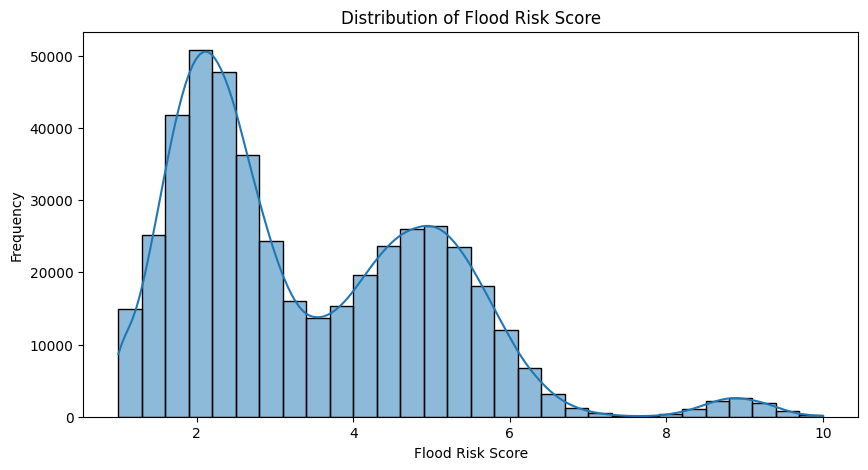

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean['flood_risk_score'],
    bins=30,
    kde=True
)

plt.title('Distribution of Flood Risk Score')
plt.xlabel('Flood Risk Score')
plt.ylabel('Frequency')
plt.show()

### 11) Correlation ของตัวแปร

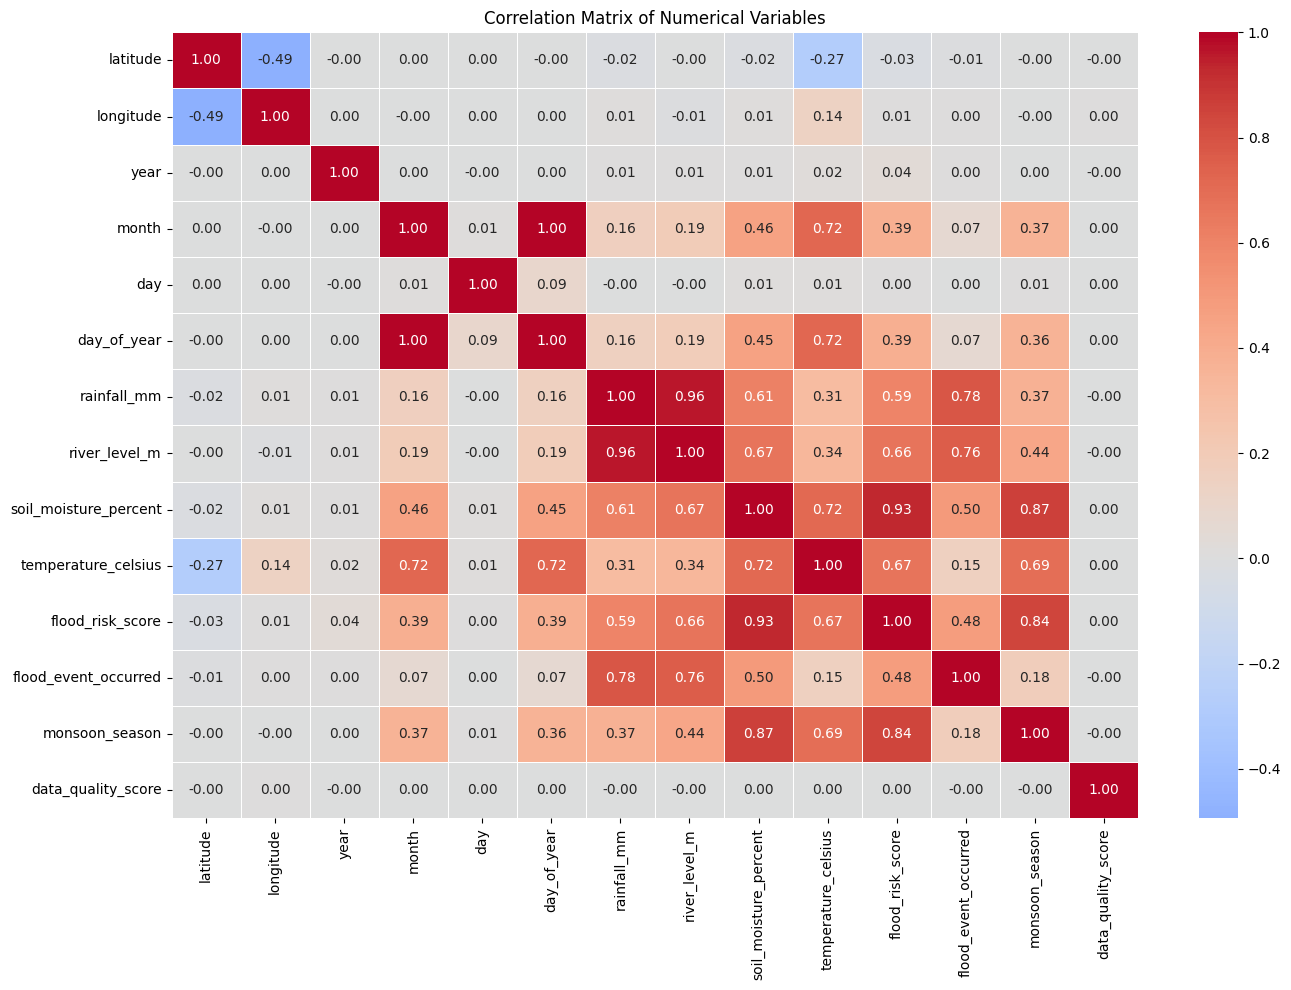

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# เลือกเฉพาะตัวแปรตัวเลข
df_numeric = df_clean.select_dtypes(include='number')

# คำนวณ Correlation
corr_matrix = df_numeric.corr()

# Plot Heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

* ดูเฉพาะ Correlation ของ flood_risk_score

In [ ]:
# ทุกความสัมพันธ์
corr_with_target = (
    df_clean
    .select_dtypes(include='number')
    .corr()['flood_risk_score']
    .sort_values(ascending=False)
)


# ดูเฉพาะความสัมพันธ์สูง  |Correlation| >= 0.3
'''
strong_corr = corr_with_target[abs(corr_with_target) >= 0.3].sort_values(
    key=abs,
    ascending=False
)
print(strong_corr)
'''
print(corr_with_target)

flood_risk_score         1.000000
soil_moisture_percent    0.933727
monsoon_season           0.844772
temperature_celsius      0.673019
river_level_m            0.664349
rainfall_mm              0.594862
flood_event_occurred     0.477949
month                    0.392368
day_of_year              0.390208
year                     0.036744
longitude                0.005967
day                      0.002746
data_quality_score       0.000579
latitude                -0.026736
Name: flood_risk_score, dtype: float64


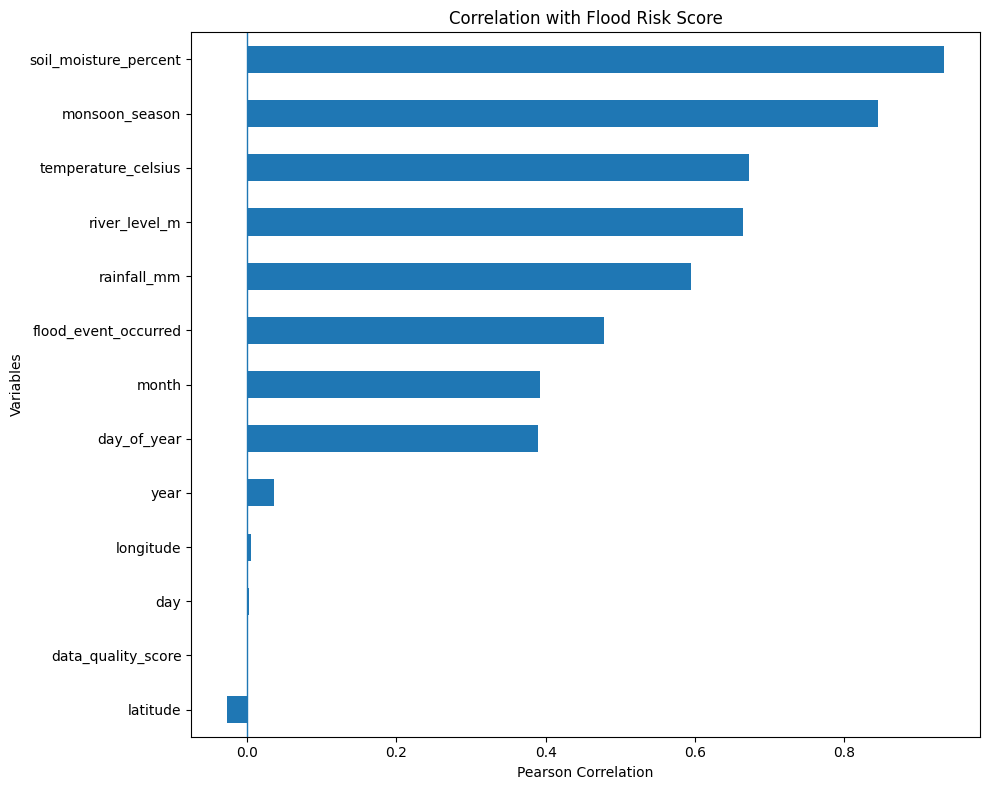

In [ ]:
plt.figure(figsize=(10, 8))

corr_with_target.drop('flood_risk_score').sort_values().plot(
    kind='barh'
)

plt.axvline(0, linewidth=1)

plt.title('Correlation with Flood Risk Score')
plt.xlabel('Pearson Correlation')
plt.ylabel('Variables')

plt.tight_layout()
plt.show()

* การตีความ

|       Correlation | ความสัมพันธ์       |
| ----------------: | ------------------ |
|   `0.70 ถึง 1.00` | สูงมาก / บวก       |
|   `0.40 ถึง 0.69` | ปานกลางถึงสูง      |
|   `0.20 ถึง 0.39` | ต่ำถึงปานกลาง      |
|  `-0.19 ถึง 0.19` | ต่ำมาก             |
| `-0.39 ถึง -0.20` | ต่ำถึงปานกลาง / ลบ |
| `-0.69 ถึง -0.40` | ปานกลางถึงสูง / ลบ |
| `-1.00 ถึง -0.70` | สูงมาก / ลบ        |


### 12) ตรวจ Data Leakage (ข้อมูลรั่วไหล) สำหรับ ML

In [ ]:
df_clean_leakage = df_clean.copy()

In [ ]:
df_clean_leakage['soil_moisture_percent'].head()

,soil_moisture_percent
0,15.66
1,27.19
2,18.11
3,19.20
4,26.70


* ex. flood_risk_score


```
ถ้าเราเอา flood_risk_score เข้าไปเป็น Feature ด้วย
โมเดลจะเห็นคำตอบอยู่แล้ว → Data Leakage
```



การตรวจ Data Leakage ก่อนทำ ML
  1) กำหนด Target ก่อน


In [ ]:
target = 'flood_risk_score'

X = df_clean_leakage.drop(columns=[target])
y = df_clean_leakage[target]

ตรวจว่า Target อยู่ใน Feature หรือไม่

In [ ]:
print("Target:", target)
print("Target อยู่ใน X หรือไม่:", target in X.columns)

Target: flood_risk_score
Target อยู่ใน X หรือไม่: False


  2. ตรวจ Column ที่อาจเป็น Leakage

In [ ]:
# เริ่มจากดูชื่อ Column ทั้งหมด

for col in df_clean_leakage.columns:
    print(col)

station_id
station_name
basin
country
latitude
longitude
date
year
month
day
day_of_year
rainfall_mm
river_level_m
soil_moisture_percent
temperature_celsius
flood_risk_score
flood_event_occurred
severity_level
season
monsoon_season
data_quality_score


In [ ]:
# จากนั้นค้นหา Column ที่มีคำที่น่าสงสัย

suspicious_keywords = [
    'flood',
    'risk',
    'target',
    'label',
    'score',
    'future',
    'outcome',
    'event',
    'damage'
] # <- ค้นหาคอลัมน์ที่มีชื่อแบบนี้

suspicious_columns = [
    col for col in df_clean_leakage.columns
    if any(keyword in col.lower() for keyword in suspicious_keywords)
]

print("Potential Leakage Columns:")
for col in suspicious_columns:
    print("-", col)

Potential Leakage Columns:
- flood_risk_score
- flood_event_occurred
- data_quality_score


<font color = #FA8072 > การเจอคำว่า flood หรือ risk ไม่ได้แปลว่าเป็น Leakage ทันที ต้องตรวจความหมายของแต่ละ Column

  3. ตรวจ Correlation กับ Target

In [ ]:
# ใช้สำหรับหา Feature ที่มีความสัมพันธ์กับ Target สูงผิดปกติ

corr = (
    df_clean_leakage
    .select_dtypes(include='number')
    .corr()['flood_risk_score']
    .drop('flood_risk_score')
    .sort_values(key=abs, ascending=False)
)

print(corr)

soil_moisture_percent    0.933727
monsoon_season           0.844772
temperature_celsius      0.673019
river_level_m            0.664349
rainfall_mm              0.594862
flood_event_occurred     0.477949
month                    0.392368
day_of_year              0.390208
year                     0.036744
latitude                -0.026736
longitude                0.005967
day                      0.002746
data_quality_score       0.000579
Name: flood_risk_score, dtype: float64


In [ ]:
# ดู Feature ที่มี Correlation สูงมาก

high_corr = corr[abs(corr) >= 0.90]

print("High Correlation Features:")
print(high_corr)

High Correlation Features:
soil_moisture_percent    0.933727
Name: flood_risk_score, dtype: float64


In [ ]:
df_clean_leakage['soil_moisture_percent'].head()

,soil_moisture_percent
0,15.66
1,27.19
2,18.11
3,19.20
4,26.70


<font color = #FA8072 > ++ บางครั้งค่าความสัมพันธ์ที่มีค่า 0.90+ ไม่ได้แปลว่า Leakage แน่นอน เพราะอาจเป็น Feature ที่มีความสัมพันธ์กับความเสี่ยงจริง ๆ

* 1. soil_moisture_percent = 0.9337

ต้องทำการตรวจสอบว่า flood_risk_score ถูกคำนวณโดยใช้ soil_moisture_percent หรือไม่?

* 2. monsoon_season = 0.8448

ต้องดูว่า monsoon_season สร้างจากอะไร

  4. ตรวจว่า Feature ถูกสร้างมาจาก Target หรือไม่

In [ ]:
df_leakage_test = df_clean_leakage.copy()

* ตรวจความสัมพันธ์ของ soil_moisture_percent

In [ ]:
df_leakage_test['soil_moisture_leakage'] = (
    df_leakage_test['flood_risk_score'] > 0.7
).astype(int)

In [ ]:
print("df_clean_leakage")
print(df_clean_leakage['soil_moisture_percent'].describe())

print("\nUnique values:")
print(df_clean_leakage['soil_moisture_percent'].nunique())

print("\nValue counts:")
print(df_clean_leakage['soil_moisture_percent'].value_counts().head(20))

df_clean_leakage
count    456600.000000
mean         36.938060
std          18.149693
min           0.390000
25%          22.070000
50%          31.000000
75%          52.570000
max         100.000000
Name: soil_moisture_percent, dtype: float64

Unique values:
6751

Value counts:
soil_moisture_percent
100.00    9153
22.34      183
21.66      182
21.55      181
21.76      180
20.07      179
21.15      179
22.13      179
21.84      179
21.03      177
21.13      177
20.62      177
23.18      176
23.12      176
21.79      175
23.86      175
21.02      175
20.34      173
23.65      173
19.94      173
Name: count, dtype: int64


In [ ]:
print("df_clean_leakage")
print(df_leakage_test['soil_moisture_percent'].describe())

print("\nUnique values:")
print(df_leakage_test['soil_moisture_percent'].nunique())

print("\nValue counts:")
print(df_leakage_test['soil_moisture_percent'].value_counts())

df_clean_leakage
count    456600.000000
mean         36.938060
std          18.149693
min           0.390000
25%          22.070000
50%          31.000000
75%          52.570000
max         100.000000
Name: soil_moisture_percent, dtype: float64

Unique values:
6751

Value counts:
soil_moisture_percent
100.00    9153
22.34      183
21.66      182
21.55      181
21.76      180
          ... 
3.78         1
72.77        1
5.46         1
3.99         1
99.25        1
Name: count, Length: 6751, dtype: int64


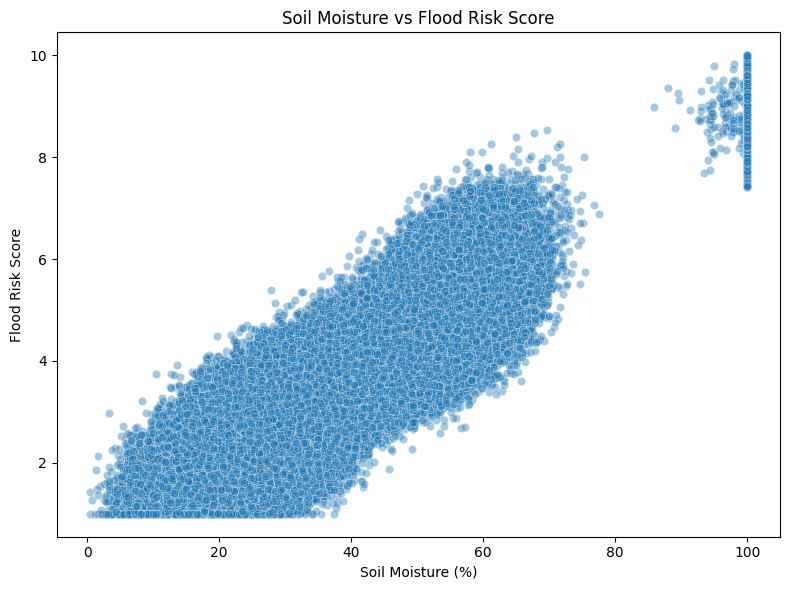

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_leakage_test,
    x='soil_moisture_percent',
    y='flood_risk_score',
    alpha=0.4
)

plt.title('Soil Moisture vs Flood Risk Score')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Flood Risk Score')

plt.tight_layout()
plt.show()

คือ ความชื้นในดินสูง → Flood Risk สูงขึ้น

ในเชิง Domain Knowledge ถือว่าสมเหตุสมผล เพราะเมื่อดินมีความชื้นสูงมาก ความสามารถในการดูดซับน้ำฝนเพิ่มเติมอาจลดลง ทำให้ runoff และความเสี่ยงน้ำท่วมเพิ่มขึ้น

<font color = pink>

ตรวจ

1. ดูจำนวนค่าที่ไม่ซ้ำ

In [ ]:
print(
    "Unique values:",
    df_leakage_test['soil_moisture_percent'].nunique()
)


Unique values: 6751


* ตรวจ monsoon_season

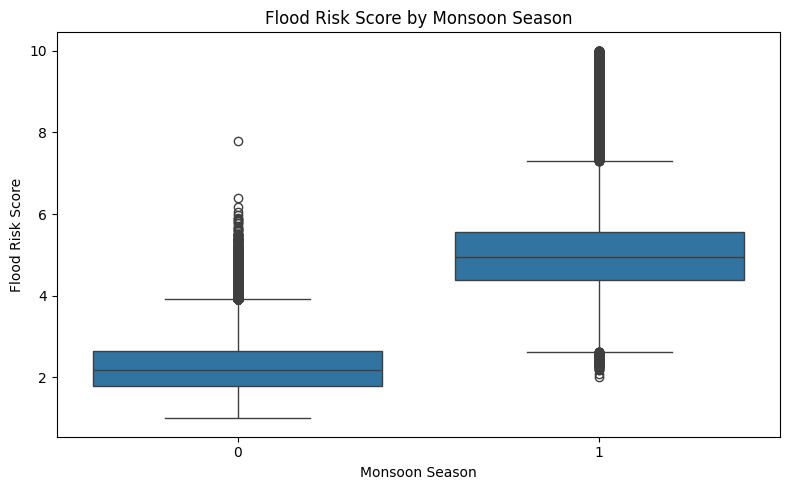

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_leakage_test,
    x='monsoon_season',
    y='flood_risk_score'
)

plt.title('Flood Risk Score by Monsoon Season')
plt.xlabel('Monsoon Season')
plt.ylabel('Flood Risk Score')

plt.tight_layout()
plt.show()

monsoon_season คือ ช่วงฤดูมรสุม
ก็ยังสมเหตุสมผลเพราะ ถ้าเป็นช่วงมรสุม นั่นแปลว่าต้องมีพายุฝน ทำให้มีปริมาณน้ำฝนมากกว่าปกติ อาจหนักถึงขั้นทำให้เกิดน้ำท้วมได้

In [ ]:
print(
    df_leakage_test.groupby('monsoon_season')['flood_risk_score']
    .agg(['count', 'mean', 'median', 'min', 'max'])
)

                 count      mean  median   min    max
monsoon_season                                       
0               265350  2.243409    2.19  1.00   7.78
1               191250  5.097778    4.96  2.02  10.00


In [ ]:
df_leakage_test[
    [
        'soil_moisture_percent',
        'monsoon_season',
        'temperature_celsius',
        'river_level_m',
        'rainfall_mm',
        'flood_event_occurred',
        'flood_risk_score'
    ]
].head(20)

,soil_moisture_percent,monsoon_season,temperature_celsius,river_level_m,rainfall_mm,flood_event_occurred,flood_risk_score
0,15.66,0,21.30,1.35,4.55,0,1.89
1,27.19,0,18.48,3.70,5.58,0,1.89
2,18.11,0,20.93,3.51,9.93,0,2.53
3,19.20,0,19.86,2.91,5.72,0,2.28
4,26.70,0,17.37,4.53,9.45,0,2.55
5,19.86,0,16.95,3.06,7.19,0,2.73
6,18.01,0,19.70,3.13,4.88,0,1.28
7,18.57,0,20.29,3.01,10.19,0,2.33
8,18.72,0,19.45,2.51,5.16,0,1.56
9,20.65,0,17.18,3.67,12.11,0,2.50


In [ ]:
print(
    pd.crosstab(
        df_leakage_test['month'],
        df_leakage_test['monsoon_season']
    )
)

monsoon_season      0      1
month                       
1               38750      0
2               35350      0
3               38750      0
4               37500      0
5               38750      0
6                   0  37500
7                   0  38750
8                   0  38750
9                   0  37500
10                  0  38750
11              37500      0
12              38750      0


  5. ตรวจ Leakage จากเวลา

  6. ตรวจ Date Column (รวมกับข้อด้านบน)

In [ ]:
df_leakage_datetime = df_clean_leakage.copy()

5.1. ตรวจสอบคอลัมน์ year, month, day, day_of_year

In [ ]:
print(df_leakage_datetime.columns.tolist())

['station_id', 'station_name', 'basin', 'country', 'latitude', 'longitude', 'date', 'year', 'month', 'day', 'day_of_year', 'rainfall_mm', 'river_level_m', 'soil_moisture_percent', 'temperature_celsius', 'flood_risk_score', 'flood_event_occurred', 'severity_level', 'season', 'monsoon_season', 'data_quality_score']


* ตรวจสอบว่า Dataset นี้มีคอลัมน์วันที่เต็มหรือไม่

In [ ]:
date_cols = [
    col for col in df_leakage_datetime.columns
    if any(x in col.lower() for x in ['date', 'time', 'datetime'])
]

print("Date/Time columns:")
print(date_cols)

Date/Time columns:
['date']


columns ['date'] is fuall date

5.2. มีคอลัมน์วันที่เต็ม ต่อไปตรวจสอบช่วงเวลา

In [ ]:
df_leakage_datetime['date'] = pd.to_datetime(df_leakage_datetime['date'])

print("Start date:", df_leakage_datetime['date'].min())
print("End date:", df_leakage_datetime['date'].max())

Start date: 2000-01-01 00:00:00
End date: 2024-12-31 00:00:00


* ดูจำนวนข้อมูลแต่ละปี

In [ ]:
print(
    df_leakage_datetime['date']
    .dt.year
    .value_counts()
    .sort_index()
)

date
2000    18300
2001    18250
2002    18250
2003    18250
2004    18300
2005    18250
2006    18250
2007    18250
2008    18300
2009    18250
2010    18250
2011    18250
2012    18300
2013    18250
2014    18250
2015    18250
2016    18300
2017    18250
2018    18250
2019    18250
2020    18300
2021    18250
2022    18250
2023    18250
2024    18300
Name: count, dtype: int64


5.3. ตรวจว่าข้อมูลเรียงตามเวลาหรือไม่

In [ ]:
df_time = df_leakage_datetime.sort_values('date').copy()

print(
    df_time[['date', 'year', 'month', 'day']]
    .head(10)
)

             date  year  month  day
0      2000-01-01  2000      1    1
383544 2000-01-01  2000      1    1
191772 2000-01-01  2000      1    1
200904 2000-01-01  2000      1    1
210036 2000-01-01  2000      1    1
374412 2000-01-01  2000      1    1
219168 2000-01-01  2000      1    1
228300 2000-01-01  2000      1    1
365280 2000-01-01  2000      1    1
237432 2000-01-01  2000      1    1


In [ ]:
print(
    "sorted correctly:",
    df_time['date'].is_monotonic_increasing
)

sorted correctly: True


5.4. ตรวจว่ามีวันที่ซ้ำหรือไม่

In [ ]:
# This dataset contains multiple stations, so duplicate dates are not unusual.
# ตรวจสอบว่ามีวันที่ซ้ำในสถานีเดียวกันหรือไม่

print(
    df_leakage_datetime.duplicated(
        subset=['station_id', 'date']
    ).sum()
)

0


5.5. ตรวจว่า Feature ใช้ข้อมูลอนาคตหรือไม่

5.6 ตรวจ Feature ที่เป็น Future Information

In [ ]:
future_keywords = [
    'future',
    'next',
    'lead',
    'forecast',
    'tomorrow',
    'next_day',
    'next_week',
    'next_month',
    'next_year',
    't_plus'
] #ตรวจเช็คคำใน Dataset ว่ามีคำเหล่านี้หรือไม่

future_cols = [
    col for col in df_leakage_datetime.columns
    if any(keyword in col.lower() for keyword in future_keywords)
]

print("potential future-information columns:")
print(future_cols)

potential future-information columns:
[]


5.7. flood_event_occurred ตรวจเป็นพิเศษ

In [ ]:
print(
    df_leakage_datetime['flood_event_occurred']
    .value_counts(dropna=False)
)

flood_event_occurred
0    446711
1      9889
Name: count, dtype: int64


* ต่อไป ดูความสัมพันธ์กับวันที่:

In [ ]:
print(
    df_leakage_datetime.groupby('flood_event_occurred')['year']
    .agg(['min', 'max', 'count'])
)

                       min   max   count
flood_event_occurred                    
0                     2000  2024  446711
1                     2000  2024    9889


* ความหมายของตัวแปร

  - flood_event_occurred = 1


```
หมายถึง:

    "วันนี้เกิดน้ำท่วม"

และ Target คือ:

"ทำนาย Flood Risk ของวันนี้"
```

ก็ต้องระวังมาก เพราะ flood_event_occurred อาจเป็นข้อมูลที่เกิดขึ้นพร้อมกับ Target


5.8. ตรวจความสัมพันธ์ของ Flood Event กับ Risk

In [ ]:
print(
    df_leakage_datetime.groupby('flood_event_occurred')['flood_risk_score']
    .agg(['count', 'mean', 'median', 'min', 'max'])
)

                       count      mean  median   min   max
flood_event_occurred                                      
0                     446711  3.320434    2.86  1.00   7.0
1                       9889  8.794037    8.86  7.01  10.0


เราต้องถามว่า:


> ตอนที่โมเดลทำนาย Risk เรารู้ flood_event_occurred แล้วหรือยัง?


ถ้ายังไม่รู้ → ห้ามใช้

5.9. ตรวจ Time Leakage ด้วยการแบ่ง Train/Test ตามเวลา

* สำหรับชุดข้อมูลนี้ จำไม่แนะนำให้ใช่ Random Spliut เป้นหลัก เพราะมีข้อมูลของวัน เดือน ปี จะทำให้ ข้อมูลอนาคตและอดีตปนกัน



```
Train     test
2020      2020
2021      2021
2022      2022
2023      2023
2024      2024


```



5.10. ใช้ Time-based Split

ในชุดข้อมูลของเรามีปี 2000-2024


สามารถแบ่งได้ดังนี้:

```
TRAIN                         TEST
2000 ─────────────── 2021 | 2022 ─────── 2024
```

In [ ]:
df_time = df_leakage_datetime.sort_values('date').copy()

train = df_time[df_time['date'] < '2022-01-01']
test = df_time[df_time['date'] >= '2022-01-01']

print("Train size:", len(train))
print(train['date'].min(), "->", train['date'].max())

print("Test size:", len(test))
print(test['date'].min(), "->", test['date'].max())

Train size: 401800
2000-01-01 00:00:00 -> 2021-12-31 00:00:00
Test size: 54800
2022-01-01 00:00:00 -> 2024-12-31 00:00:00


5.11. ตรวจว่า Train ไม่มีข้อมูลหลัง Test

In [ ]:
print("Train max data:",
      train['date'].max())

print("Test min data:",
      test['date'].min())

print(
    "Time leakage:",
    train['date'].max() >= test['date'].min()
)

Train max data: 2021-12-31 00:00:00
Test min data: 2022-01-01 00:00:00
Time leakage: False


5.12. ตรวจสอบแต่ละสถานีมีข้อมูลต่อเนื่องหรือไม่

In [ ]:
print(
    df_leakage_datetime.groupby('station_id')['date']
    .agg(['min', 'max', 'count'])
    .head(20)
)

                  min        max  count
station_id                             
ASIA_0001  2000-01-01 2024-12-31   9132
ASIA_0002  2000-01-01 2024-12-31   9132
ASIA_0003  2000-01-01 2024-12-31   9132
ASIA_0004  2000-01-01 2024-12-31   9132
ASIA_0005  2000-01-01 2024-12-31   9132
ASIA_0006  2000-01-01 2024-12-31   9132
ASIA_0007  2000-01-01 2024-12-31   9132
ASIA_0008  2000-01-01 2024-12-31   9132
ASIA_0009  2000-01-01 2024-12-31   9132
ASIA_0010  2000-01-01 2024-12-31   9132
ASIA_0011  2000-01-01 2024-12-31   9132
ASIA_0012  2000-01-01 2024-12-31   9132
ASIA_0013  2000-01-01 2024-12-31   9132
ASIA_0014  2000-01-01 2024-12-31   9132
ASIA_0015  2000-01-01 2024-12-31   9132
ASIA_0016  2000-01-01 2024-12-31   9132
ASIA_0017  2000-01-01 2024-12-31   9132
ASIA_0018  2000-01-01 2024-12-31   9132
ASIA_0019  2000-01-01 2024-12-31   9132
ASIA_0020  2000-01-01 2024-12-31   9132


5.13. ตรวจ Lag Feature

ถ้าคุณต้องการทำนาย วันถัดไป เราสามารถใช้ข้อมูลของวันก่อนหน้าได้

In [ ]:
df_leakage_datetime['rainfall_lag1'] = (
    df_leakage_datetime.groupby('station_id')['rainfall_mm']
    .shift(1)
    # ห้ามเป็น -1 เพราะจะเป็นการใช้ข้อมูล rainfall ของอีก 1 วันข้างหน้า ไม่ใช่ของวันก่อนหน้า
)

ความหมายคือ:

```
วันที่ 1 → rainfall_lag1 = NaN
วันที่ 2 → rainfall_lag1 = rainfall วันที่ 1
วันที่ 3 → rainfall_lag1 = rainfall วันที่ 2
```

แบบนี้ ไม่ Leakage เพราะใช้ข้อมูลในอดีต


5.14. Prediction Scenario นี้

* ถ้าเป้าหมายของโปรเจคที่เราทำคือการ [Predict Flood Rick ล่วงหน้า]
เราควรกำหนดขั้นตอนดังนี้:

Prediction Scenario นี้

```
ข้อมูลวันที่ T
        ↓
       ML
        ↓
Flood Risk วันที่ T+1
```

ดังนั้น Feature ควรเป็น:

```
rainfall(t)
river_level(t)
soil_moisture(t)
temperature(t)
monsoon_season(t)
```

หรือเพิ่มข้อมูลย้อนหลัง:

```
rainfall(t-1)
rainfall(t-2)
river_level(t-1)
soil_moisture(t-1)
```



แต่ Target:

```
flood_risk_score(t+1)
```

แบบนี้จะเป็นโจทย์ ML ที่ชัดเจนและลดความเสี่ยง Time Leakage ได้มาก

Checklist สำหรับ Time Leakage ของ Dataset นี้

```
1. มี Date/Datetime จริงหรือไม่
        ↓
2. ข้อมูลเรียงตามเวลาไหม
        ↓
3. มีวันที่ซ้ำหรือไม่
        ↓
4. มี Feature ที่มาจากอนาคตหรือไม่
        ↓
5. flood_event_occurred เกิดก่อน/พร้อม/หลัง Target?
        ↓
6. Feature Engineering ใช้ข้อมูลอนาคตหรือไม่
        ↓
7. Train/Test แบ่งตามเวลาหรือไม่
        ↓
8. มี shift(-1), rolling ที่ผิดฝั่งหรือไม่
        ↓
9. ถ้ามีหลายสถานี ตรวจ station + date
        ↓
10. Train ต้องไม่เห็นข้อมูลอนาคตของ Test
```




* ชุดตรวจสอบแรก

In [ ]:
print("=== COLUMNS ===")
print(df_leakage_datetime.columns.tolist())

print("\n=== DATE COLUMNS ===")
date_cols = [
    col for col in df_leakage_datetime.columns
    if any(x in col.lower() for x in ['date', 'time', 'datetime'])
]
print(date_cols)

print("\n=== YEAR ===")
print(df_leakage_datetime['year'].min(), "→", df_leakage_datetime['year'].max())

print("\n=== FLOOD EVENT ===")
print(df_leakage_datetime['flood_event_occurred'].value_counts(dropna=False))

print("\n=== DATA SHAPE ===")
print(df_leakage_datetime.shape)

=== COLUMNS ===
['station_id', 'station_name', 'basin', 'country', 'latitude', 'longitude', 'date', 'year', 'month', 'day', 'day_of_year', 'rainfall_mm', 'river_level_m', 'soil_moisture_percent', 'temperature_celsius', 'flood_risk_score', 'flood_event_occurred', 'severity_level', 'season', 'monsoon_season', 'data_quality_score', 'rainfall_lag1']

=== DATE COLUMNS ===
['date']

=== YEAR ===
2000 → 2024

=== FLOOD EVENT ===
flood_event_occurred
0    446711
1      9889
Name: count, dtype: int64

=== DATA SHAPE ===
(456600, 22)


  7. ตรวจ Leakage จาก Scaling

  8. ตรวจ Leakage จาก Imputation

  9. วิธีที่แนะนำที่สุด: ใช้ Pipeline

  10. ตรวจ Leakage ด้วย Baseline Model

  11. Checklist สำหรับ Dataset

                    DATASET
                       │
                       ▼
              ┌─────────────────┐
              │ กำหนด Target    │
              │ flood_risk_score │
              └────────┬────────┘
                       ▼
              ตรวจ Target Leakage
                       │
                       ▼
              ตรวจ Feature Leakage
                       │
                       ▼
                ตรวจ Date/Time
                       │
                       ▼
             ตรวจ Future Information
                       │
                       ▼
                  Split Data
                       │
              ┌────────┴────────┐
              ▼                 ▼
            TRAIN              TEST
              │
              ▼
       Fit Imputer/Scaler
              │
              ▼
           Train ML
              │
              ▼
          Evaluate TEST

### 13) วิเคราะห์ว่า Target ไหนเหมาะที่สุด

### 14) สรุป Data Cleaning Plan

### 15) วาง Feature Engineering ที่เหมาะกับ Dataset จริง

## <font color = EF6905> step 4 : Exploratory Data Analysis - EDA

## <font color = EF6905> step 5 : Data Modeling

## <font color = EF6905> step 6 : Model Evaluation

## <font color = EF6905> step 7 : Deployment & Monitoring